In [1]:
import numpy as np
import pandas as pd
import os

from matplotlib import pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable

rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 6
%config InlineBackend.figure_format='retina'

import cooler

import itertools

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from statsmodels.regression.linear_model import OLS

from scipy.stats import spearmanr, pearsonr

loops_df = pd.read_csv('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/final_loop_data.csv', index_col=0, usecols=[0,1,2,3,34])
loops_df_full = pd.read_csv('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/final_loop_data.csv', index_col=0)

dataset_names = ['YY1_GSE99518', 'Klf5_GSE49848', 'Esrrb_GSE90893', 'Cbx3_GSE44242', 'H3K27me3_GSE90893', 'SMC1A_GSE123636', 'Nanog_GSE71932', 'ATAC_GSE98390', 'H3K4me1_GSE90893', 'cMyc_GSE90893', 'Oct4_GSE90893', 'Klf4_GSE90893', 'Ring1b_GSE96107', 'H3K4me2_GSE90893', 'Sp1_GSE52496', 'Sox2_GSE90893', 'RAD21_GSE90994', 'Hira_GSE42152', 'P300_GSE90893', 'Brg1_GSE90893', 'Ezh2_GSE85717', 'Ino80_GSE49137', 'HP1b_GSE64946', 'H4ac_GSE76760', 'Med1_GSE22562', 'H3K27ac_GSE90893', 'H3K79me2_GSE90893', 'H4K20me3_GSE26680', 'H2AZ_GSE34483', 'H4R3me2_GSE37604', 'Brd4_GSE87037', 'H3K9me2_GSE54412', 'RNAPII_GSE58019', 'CTCF_GSE90994', 'H3K4me3_GSE90893', 'Daxx_GSE70811', 'Top2a_GSE45625', 'H3K9me3_GSE90893', 'Tbp_GSE70661', 'H3K9ac_GSE90893', 'H3K36me3_GSE90893', 'Med12_GSE22562', 'GROseq_GSE69142']
feature_names = [s.split('_')[0] for s in dataset_names]

for dataset in dataset_names:
    anchor_signal_data = np.loadtxt(f'/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/bigwig_signal_at_anchors/{dataset}_normalized_signal_at_anchors_pad_2.5kb.txt')
    loops_df[f'{dataset.split("_")[0]}_L'] = anchor_signal_data[:,0]
    loops_df[f'{dataset.split("_")[0]}_R'] = anchor_signal_data[:,1]
    
loops_df


,chr,left,right,abs_loop_percent,YY1_L,YY1_R,Klf5_L,Klf5_R,Esrrb_L,Esrrb_R,...,Tbp_L,Tbp_R,H3K9ac_L,H3K9ac_R,H3K36me3_L,H3K36me3_R,Med12_L,Med12_R,GROseq_L,GROseq_R
64,chr1,9771500,9839500,-0.698958,365.470,159.250,509.840,149.690,811.940,166.530,...,957.790,265.140,1888.600,293.400,56.985,57.181,485.47,78.660,429.25000,25.0050
65,chr1,9818500,9918500,0.005046,223.760,217.490,236.540,341.040,176.680,330.630,...,232.910,208.550,1448.600,588.090,137.120,87.285,260.07,217.350,112.52000,34.3620
68,chr1,9841500,9917500,0.180054,159.100,202.540,155.550,331.210,131.030,324.080,...,206.050,189.280,193.450,576.120,47.160,69.050,105.23,204.930,13.84800,37.1380
69,chr1,9841500,9962500,0.723321,159.100,97.687,155.550,75.293,131.030,306.040,...,206.050,135.020,193.450,59.573,47.160,111.970,105.23,67.045,13.84800,24.2480
70,chr1,9855500,9931500,0.983538,71.647,80.854,38.755,60.984,44.491,58.936,...,122.560,79.425,44.330,32.395,56.592,87.757,18.63,54.165,2.56140,17.7030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424284,chrX,162967500,163180500,7.091275,52.750,53.717,60.984,96.096,65.484,203.000,...,75.895,70.459,18.755,71.610,27.510,101.750,35.19,65.148,0.95353,26.2620
424285,chrX,162966500,163232500,8.146901,47.783,45.105,53.592,36.960,76.847,115.240,...,65.305,66.293,26.768,22.165,21.615,38.435,28.98,43.470,1.27140,3.7624
424286,chrX,162967500,163070500,7.416004,52.750,48.360,60.984,35.059,65.484,65.484,...,75.895,84.720,18.755,18.175,27.510,135.580,35.19,59.973,0.95353,50.8720
424287,chrX,163086500,163232500,2.457245,45.421,45.105,39.811,36.960,39.290,115.240,...,58.245,66.293,25.575,22.165,167.770,38.435,35.19,43.470,28.55800,3.7624


In [2]:
loops_df.to_csv('/mnt/md0/jjusuf/absloopquant_loop_data_with_epigenomics.csv')

In [3]:
# filter for specific category
#loops_df = loops_df.loc[loops_df_full['pure_CC']]

y = loops_df['abs_loop_percent']
X_raw = loops_df.iloc[:,4:]

# remove data points with zero values
no_zero_values = np.logical_and(np.sum(X_raw==0, 1)==0, y>0)
y, X_raw = y.loc[no_zero_values], X_raw.loc[no_zero_values]
indices_keep = np.array(X_raw.index)

# add extra column for loop size
sizes = loops_df.loc[indices_keep, 'right']-loops_df.loc[indices_keep, 'left']
X_raw_with_sizes = np.concatenate((X_raw, np.reshape(sizes, (len(sizes), 1))), axis=1)

# take the log
X = np.log10(X_raw_with_sizes)
y = np.log10(y)

# perform scaling
scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(np.reshape(y, (-1, 1)))[:,0]

# remove data points that are outliers
not_outlier = np.logical_and(np.sum(np.abs(X_scaled)>4, 1)==0, np.abs(y_scaled>4)==0)
y_scaled, X_scaled = y_scaled[not_outlier], X_scaled[not_outlier]
indices_keep = indices_keep[not_outlier]

num_loops = len(X_scaled)
print(f'{num_loops} loops')

np.random.seed(5129)

# split into training and testing
num_train = int(np.round(num_loops * 0.8))
num_test = num_loops-num_train
print(f'Using {num_train} loops for training, {num_test} loops for testing')
train_sel = np.repeat(False, len(X_scaled))
train_indices = np.random.choice(np.arange(len(X_scaled)), num_train, replace=False)
train_sel[train_indices] = True
X_train = X_scaled[train_sel,:]
y_train = y_scaled[train_sel]
X_test = X_scaled[~train_sel,:]
y_test = y_scaled[~train_sel]

# double the training set by adding new flipped data points (enforce symmetry)
X_flipped = np.zeros(X_train.shape)
X_flipped[:,:-1:2] = X_train[:,1:-1:2]
X_flipped[:,1:-1:2] = X_train[:,:-1:2]
X_train_doubled = np.concatenate((X_train, X_flipped))
y_train_doubled = np.concatenate((y_train, y_train))


51821 loops
Using 41457 loops for training, 10364 loops for testing


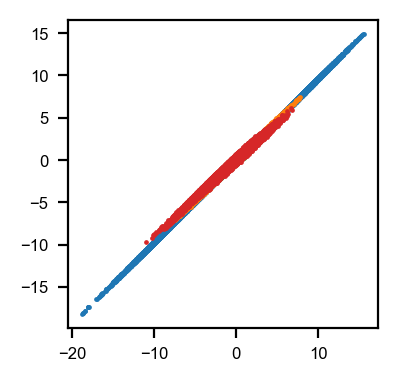

In [20]:
# perform PLSR
ncomp = 4
pls1 = PLSRegression(n_components=ncomp)
pls1.fit(X_train_doubled, y_train_doubled);

# get the R weights matrix
R = pls1.x_weights_ @ np.linalg.inv(pls1.x_loadings_.T @ pls1.x_weights_)

# verify that R is actually the weights matrix (not exact, due to numerical instability)
plt.figure(figsize=(2,2))
for i in range(ncomp):
    plt.scatter(pls1.x_scores_[:,i], np.matmul(X_train_doubled, R)[:,i], 0.5);


0.27168527698577327


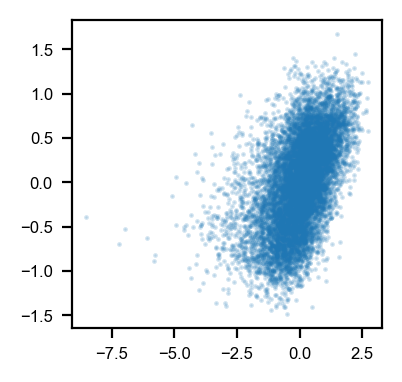

In [21]:
# make plot of actual vs. predicted y (in standardized log space)
y_actual = y_test
y_pred = (pls1.transform(X_test) @ pls1.y_weights_.T).flatten()
plt.figure(figsize=(2,2))
plt.scatter(y_actual, y_pred, s=0.5, alpha=0.2)
print(r2_score(y_actual, y_pred));


In [22]:
# define function to perform varimax transformation
# code from Wikipedia: https://en.wikipedia.org/wiki/Talk:Varimax_rotation

def varimax(Phi, gamma = 1, q = 20, tol = 1e-6):
    from numpy import eye, asarray, dot, sum, diag
    from numpy.linalg import svd
    p,k = Phi.shape
    R = eye(k)
    d=1e-12
    for i in range(q):
        d_old = d
        Lambda = dot(Phi, R)
        u,s,vh = svd(dot(Phi.T,asarray(Lambda)**3 - (gamma/p) * dot(Lambda, diag(diag(dot(Lambda.T,Lambda))))))
        R = dot(u,vh)
        d = sum(s)
        if d/d_old < tol: break
    new_scores = dot(Phi, R)
    varimax_transform = R
    return new_scores, varimax_transform


In [23]:
# perform the varimax transformation
R_varimax, varimax_transform = varimax(R)
y_weights_varimax = pls1.y_weights_ @ varimax_transform
x_scores_train_doubled_varimax = X_train_doubled @ R_varimax
x_scores_test_varimax = X_test @ R_varimax


0.2704726853135391


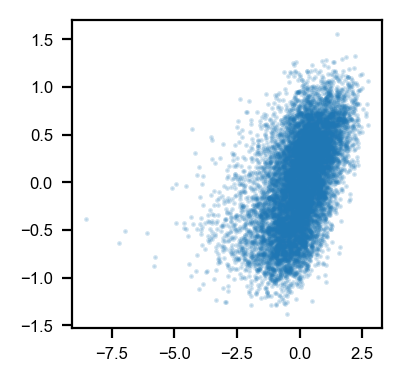

In [24]:
# verify that the new varimax rotated weights yield the same prediction results
# make plot of actual vs. predicted y (in standardized log space)
y_actual = y_test
y_pred = (x_scores_test_varimax @ y_weights_varimax.T).flatten()
plt.figure(figsize=(2,2))
plt.scatter(y_actual, y_pred, s=0.5, alpha=0.2)
print(r2_score(y_actual, y_pred));


In [25]:
list_of_binary_sel = list(itertools.product([0, 1], repeat=ncomp))
for binary_sel in list_of_binary_sel:
    sel = np.arange(ncomp)[np.array(binary_sel)==1]
    if len(sel) <= 4:
        y_pred = (x_scores_test_varimax[:,sel] @ y_weights_varimax[:,sel].T).flatten()
        y_actual = y_test
        print(f'{str(sel).ljust(10)}\t\t{r2_score(y_actual, y_pred):.4f}');


[]        		-0.0000
[3]       		0.0566
[2]       		0.0905
[2 3]     		0.1379
[1]       		0.1580
[1 3]     		0.2252
[1 2]     		0.2056
[1 2 3]   		0.2636
[0]       		0.0383
[0 3]     		0.0957
[0 2]     		0.1137
[0 2 3]   		0.1619
[0 1]     		0.1790
[0 1 3]   		0.2470
[0 1 2]   		0.2116
[0 1 2 3] 		0.2705


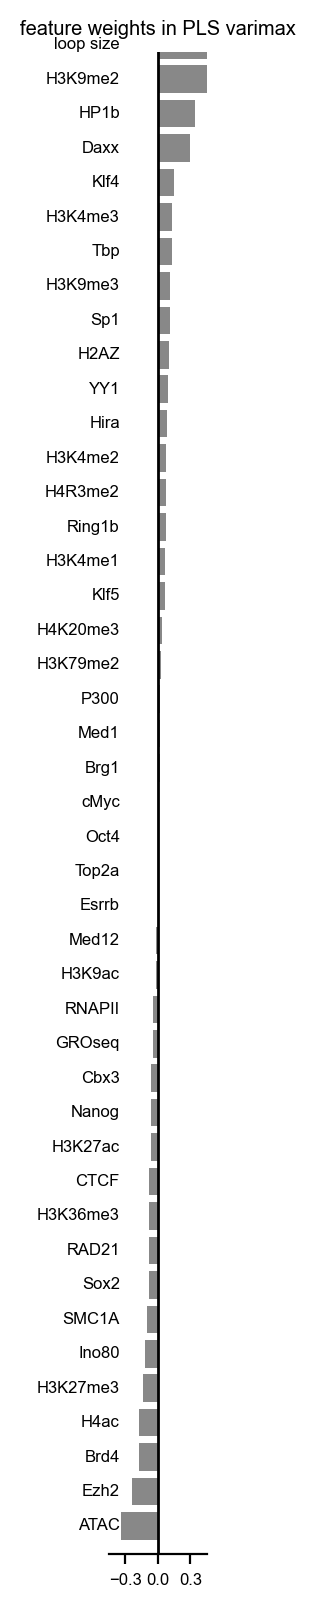

In [27]:
arr = R_varimax[:,3]
weights = pd.Series(arr[::2], index=feature_names+['loop size'])
weights = weights.sort_values(ascending=False)
names_in_order = weights.index
y_arr = np.arange(len(weights))[::-1]
fig, ax = plt.subplots(figsize=(1, 8), frameon=False)
ax.barh(y_arr, weights, color='#888888')
ax.set_yticks([])
ax.set_xlim([-0.45,0.45])
ax.set_xticks([-0.3,0,0.3]);
ax.axvline(0,0,42, color='black', linewidth=1)
for i, y_val in enumerate(y_arr):
    ax.text(-0.35, y_val, names_in_order[i], ha='right', va='center')
ax.spines[['left', 'right', 'top']].set_visible(False)
ax.set_ylim(-0.8,42.8);
ax.set_title(f'feature weights in PLS varimax');
plt.tight_layout()

In [35]:
# just take top two components in varimax
R_varimax_reduced = R_varimax[:,np.array([1,3])]
y_weights_varimax_reduced = y_weights_varimax[:,np.array([1,3])]

# flip second component
R_varimax_reduced[:,1] = -R_varimax_reduced[:,1]
y_weights_varimax_reduced[:,1] = -y_weights_varimax_reduced[:,1]

# normalize weights
scale_factor_0 = np.sqrt(np.sum(R_varimax_reduced[:,0]**2))
scale_factor_1 = np.sqrt(np.sum(R_varimax_reduced[:,1]**2))
R_varimax_reduced[:,0] /= scale_factor_0
R_varimax_reduced[:,1] /= scale_factor_1
y_weights_varimax_reduced[:,0] *= scale_factor_0
y_weights_varimax_reduced[:,1] *= scale_factor_1

x_scores_test_varimax_reduced = X_test @ R_varimax_reduced

y_pred = (x_scores_test_varimax_reduced @ y_weights_varimax_reduced.T).flatten()
y_actual = y_test
r2_score(y_actual, y_pred)


0.22516163400092604

In [36]:
np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_weights.txt', R_varimax_reduced)
np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_coeffs.txt', y_weights_varimax_reduced)

np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_X_train.txt', X_train_doubled)
np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_y_train.txt', y_train_doubled)

np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_X_test.txt', X_test)
np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_y_test.txt', y_test)

np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_X.txt', X_scaled)
np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_y.txt', y_scaled)
np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_y_raw.txt', 10**scaler_y.inverse_transform(y_scaled.reshape(1,-1)).flatten())

np.savetxt('/mnt/md0/jjusuf/absloopquant/AbsLoopQuant_data/regression_analysis_indices_keep.txt', indices_keep)
